In [106]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
df = pd.read_csv('data/cleaned_train.csv')

In [108]:
df = df.set_index('PassengerId')
y = df['Survived']
X = df.copy().drop(columns=['Survived'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [109]:
scaler = StandardScaler()
X_numeric = ['Age', 'Fare', 'GroupSize', 'FamilySize']
X_train[X_numeric] = scaler.fit_transform(X_train[X_numeric])
X_test[X_numeric] = scaler.transform(X_test[X_numeric])
X_train

,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,GroupSize,FamilySize
PassengerId,,,,,,,,,
693,3,male,-0.029183,0.513812,U,S,Mr,3.826918,-0.556339
482,2,male,-0.029183,-0.662563,U,S,Mr,-0.576151,-0.556339
528,1,male,-0.029183,3.955399,C,S,Mr,-0.576151,-0.556339
856,3,female,-0.859058,-0.467874,U,S,Mrs,-0.576151,0.073412
802,2,female,0.121703,-0.115977,U,S,Mrs,0.891539,0.703162
...,...,...,...,...,...,...,...,...,...
360,3,female,-0.632729,-0.498500,U,Q,Miss,-0.576151,-0.556339
259,1,female,0.423476,10.005329,U,C,Miss,0.891539,-0.556339
737,3,female,1.404237,0.053205,U,S,Mrs,1.625384,1.962663


In [110]:
ordinal_list = ['Sex', 'Cabin']
ohe_list = ['Embarked', 'Title']

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_list),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ohe_list)
    ],
    remainder='passthrough'
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
pd.DataFrame(X_test)

d:\Code\ML\ml_projects\Titanic_Survival_Prediction\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,1.0,8.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,3.0,-0.406399,-0.159704,0.157694,0.703162
1,1.0,8.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,3.0,1.102464,-0.327324,-0.576151,0.073412
2,1.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,3.0,-0.557286,-0.512122,-0.576151,-0.556339
3,1.0,8.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,3.0,0.876135,-0.368795,-0.576151,0.703162
4,0.0,8.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,-0.632729,-0.339817,0.157694,0.073412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,0.0,8.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,2.0,-0.330956,-0.121182,0.157694,0.073412
175,1.0,8.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,3.0,-0.708172,-0.499020,-0.576151,-0.556339
176,1.0,8.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,2.0,-0.104627,-0.443929,-0.576151,-0.556339
177,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,2.0,-0.481842,-0.375388,-0.576151,-0.556339


In [111]:
model_log = LogisticRegression(max_iter=200)
model_log.fit(X_train, y_train)
y_pred_log = model_log.predict(X_test)
models_results = []
models_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_log),
    'Precision': precision_score(y_test, y_pred_log),
    'Recall': recall_score(y_test, y_pred_log),
    'F1 Score': f1_score(y_test, y_pred_log)
})

In [112]:
model_svm = SVC()
model_svm.fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_test)
models_results.append({
    'Model': 'SVM',
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'F1 Score': f1_score(y_test, y_pred_svm)
})

In [113]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
models_results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1 Score': f1_score(y_test, y_pred_rf)
})

In [114]:
model_gb = GradientBoostingClassifier()
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)
models_results.append({
    'Model': 'Gradient Boosting',
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb),
    'Recall': recall_score(y_test, y_pred_gb),
    'F1 Score': f1_score(y_test, y_pred_gb)
})

In [115]:
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
models_results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1 Score': f1_score(y_test, y_pred_dt)
})

In [116]:
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)
models_results.append({
    'Model': 'Naive Bayes',
    'Accuracy': accuracy_score(y_test, y_pred_nb),
    'Precision': precision_score(y_test, y_pred_nb),
    'Recall': recall_score(y_test, y_pred_nb),
    'F1 Score': f1_score(y_test, y_pred_nb)
})

In [117]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)
models_results.append({
    'Model': 'KNN',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1 Score': f1_score(y_test, y_pred_knn)
})

In [118]:
model_lgbm = LGBMClassifier(n_estimators=200)
model_lgbm.fit(X_train, y_train)
y_pred_lgbm = model_lgbm.predict(X_test)
models_results.append({
    'Model': 'LightGBM',
    'Accuracy': accuracy_score(y_test, y_pred_lgbm),
    'Precision': precision_score(y_test, y_pred_lgbm),
    'Recall': recall_score(y_test, y_pred_lgbm),
    'F1 Score': f1_score(y_test, y_pred_lgbm)
})

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 228
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

d:\Code\ML\ml_projects\Titanic_Survival_Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [119]:
df_results = pd.DataFrame(models_results)
df_results = df_results.round(4)
df_results = df_results.set_index('Model')
df_results

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.8324,0.8000,0.7536,0.7761
SVM,0.8268,0.7969,0.7391,0.7669
Random Forest,0.7765,0.7231,0.6812,0.7015
Gradient Boosting,0.7877,0.7627,0.6522,0.7031
Decision Tree,0.7318,0.6567,0.6377,0.6471
Naive Bayes,0.6257,0.6667,0.0580,0.1067
KNN,0.7765,0.7302,0.6667,0.6970
LightGBM,0.7765,0.7101,0.7101,0.7101


In [120]:
models_list = {
    'Logistic Regression': model_log,
    'SVM': model_svm,
    'Random Forest': model_rf,
    'Gradient Boosting': model_gb
}

metrics = []

for name, model in models_list.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    metrics.append({
        'Model': name,
        'Mean Accuracy': scores.mean()
    })

df_metrics = pd.DataFrame(metrics)
df_metrics = df_metrics.round(4)
df_metrics = df_metrics.set_index('Model')
df_metrics

,Mean Accuracy
Model,
Logistic Regression,0.8160
SVM,0.8217
Random Forest,0.8049
Gradient Boosting,0.8259


In [121]:
param_grid_log = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

param_grid_gb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 6]
}

param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [122]:
models_list = {
    'Logistic Regression': [model_log, param_grid_log],
    'SVM': [model_svm, param_grid_svm],
    'Random Forest': [model_rf,param_grid_rf],
    'Gradient Boosting': [model_gb, param_grid_gb],
    'Decision Tree': [model_dt,param_grid_dt],
    'Naive Bayes': [model_nb, param_grid_nb],
    'KNN': [model_knn, param_grid_knn]
}

metrics = []

for name, model_values in models_list.items():
    grid_model = GridSearchCV(
        estimator=model_values[0],
        param_grid=model_values[1],
        scoring='accuracy',
        cv=5,
        n_jobs=-1
    )

    grid_model.fit(X_train, y_train)

    print(f'Best hyperparameters for {name}:', grid_model.best_params_)
    best_grid_model = grid_model.best_estimator_

    y_pred_model = best_grid_model.predict(X_test)
    
    metrics.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred_model),
        'Precision': precision_score(y_test, y_pred_model),
        'Recall': recall_score(y_test, y_pred_model),
        'F1 Score': f1_score(y_test, y_pred_model)
    })

df_metrics = pd.DataFrame(metrics)
df_metrics = df_metrics.round(4)
df_metrics = df_metrics.set_index('Model')
df_metrics  

d:\Code\ML\ml_projects\Titanic_Survival_Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best hyperparameters for Logistic Regression: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}
Best hyperparameters for SVM: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best hyperparameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Best hyperparameters for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'subsample': 0.8}
Best hyperparameters for Decision Tree: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 6, 'min_samples_split': 2}
Best hyperparameters for Naive Bayes: {'var_smoothing': 1e-05}
Best hyperparameters for KNN: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.8492,0.8182,0.7826,0.8000
SVM,0.7989,0.7797,0.6667,0.7188
Random Forest,0.7989,0.7619,0.6957,0.7273
Gradient Boosting,0.8156,0.7903,0.7101,0.7481
Decision Tree,0.7821,0.7500,0.6522,0.6977
Naive Bayes,0.7263,0.7941,0.3913,0.5243
KNN,0.7989,0.7705,0.6812,0.7231


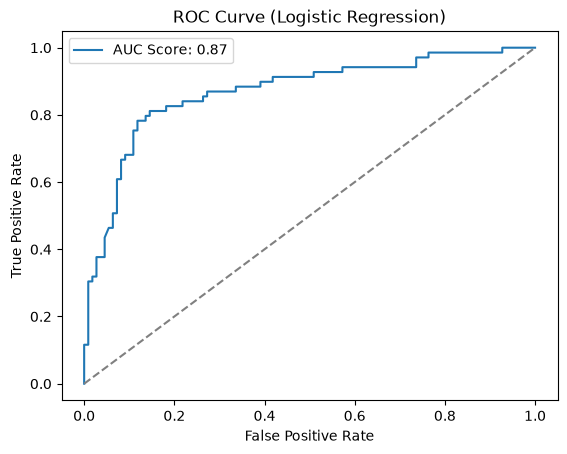

In [130]:
y_probs = model_log.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f'AUC Score: {auc_score:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Logistic Regression)')
plt.legend()
plt.show()